Full text Version

In [81]:
import torch 
import torch.nn as nn

In [82]:
import numpy as np

In [83]:
from core.basemodel import *

In [84]:
from core.data_handler import *

In [85]:
from core.optimizer import *

In [86]:
from core.fit import *

In [87]:
import matplotlib.pyplot as plt

In [88]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

In [89]:
import core.cbs

In [90]:
#from unet import Unet_sigmoid

In [91]:
from collections import OrderedDict

In [92]:
#import unet_ein as ue

In [93]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

In [94]:
import random

In [95]:
import pytorch_ssim

# Data

In [96]:
trn_ , val_ = split('../dataset/fuz attack/lka_can/normal/bin/',prc = 0.2, dataset_pct=  1, dim =(112,112), word_type=torch.float)
normal , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)

In [97]:
trn_.data= trn_.data[80*220:]
normal.data = trn_.data + val_.data
atk.data = trn_.data + val_.data+ atk.data

In [98]:
bs = 8
seq_len = 10
overlap=0

In [99]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

In [100]:
normal_dl = Sequence_dl( normal, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])
anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])

In [101]:
dl =CombineDataLoader(trn_dl,val_dl)

# Custom Loss

In [102]:
class SSIM:
    def __init__(self):
        self.ssim_loss = pytorch_ssim.SSIM(window_size = 11)
    def __call__(self,ip,tgt):
        
        if type(ip[-1]) == torch.Tensor:
            tgt_lka,tgt_vis,ip_lka,ip_vis,tgt_hist,ip_hist = ip
            
            tgt_vis = tgt_vis [None,None,None,:]
            ip_vis = ip_vis [None,None,None,:]
            tgt_hist = tgt_hist [None,None,:,:]
            ip_hist = ip_hist [None,None,:,:]
            
            
            vis = self.ssim_loss(ip_vis,tgt_vis)
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            hist = self.ssim_loss(ip_hist,tgt_hist)

            return 1 - (lka+vis*0.5+hist*0.5)            
        
        else:
            tgt_lka,tgt_vis,ip_lka,ip_vis,_,_ = ip
            
            tgt_vis = tgt_vis [None,None,None,:]
            ip_vis = ip_vis [None,None,None,:]

            
            vis = self.ssim_loss(ip_vis,tgt_vis)
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            
            return 1 - (lka+vis)
        

In [103]:
class binary:
    def __call__(self,ip,tgt):
        if type(ip[-1]) == torch.Tensor:
            tgt_lka,tgt_vis,ip_lka,ip_vis,tgt_hist,ip_hist = ip
            
            vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            hist = nn.functional.binary_cross_entropy(ip_hist,tgt_hist)

            return (lka+vis*0.9+hist*0.1)            
        
        else:
            tgt_lka,tgt_vis,ip_lka,ip_vis,_,_ = ip
            
            vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
            lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            
            return (lka+vis)

In [145]:
class mse:
    def __call__(self,ip,tgt):
        if type(ip[-1]) == torch.Tensor:
            
            _,tgt_lka,_,ip_lka,tgt_hist,ip_hist = ip
            
            lka = nn.functional.mse_loss(ip_lka[:88],tgt_lka[:88])
            vis = 0 #nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            hist = nn.functional.mse_loss(ip_hist,tgt_hist)

            return (lka+vis*0.5+hist*0.5)            
        
        else:
            _,tgt_lka,_,ip_lka,_,_ = ip
            
            lka = nn.functional.mse_loss(ip_lka[:88],tgt_lka[:88])
            vis = 0 #nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
            
            return (lka+vis)

In [146]:
loss = mse()

## Helping Methods

In [147]:
def get_vis(frame):
    new_frame = frame.type(torch.int).tolist()
    new_frame = [str(i) for i in new_frame]
    s = ''.join(new_frame)
    new_frame = s[-4:] + s[:8]
    
    return (int(new_frame,2) *0.01)-16

In [148]:
def get_frame(value):
    
    value = int((value +16 ) / 0.01)
    
    hex_value = hex(value)[2:]
    bin_value = bin(int(f"{hex_value}", 16))[2:].zfill(12)
    
    new_frame = bin_value[-8:] + bin_value[:4]
    new_frame = [float(i) for i in list(new_frame)]
    new_frame = torch.tensor(new_frame)
    return new_frame

In [149]:
#vis = np.load('../dataset/fuz attack/generated_ds/amr/array.npy')

# Model : Predict LKA
Input: VIS History + Previous VIS + VIS <br>
Input Form: Full frame<br>
Output: Prediction   LKA <br>
Training Dataset: Original<br>

In [150]:
import random


In [151]:
# 4 epoch 
#lr 1e-4
#mse
#parameter size = 1054746
#inference time = 7.576181157394465 ms/ mb
class lka_predictor(BaseModel):    
    def __init__(self,win_size):
        super().__init__()
        self.win_size= win_size
        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
        self.lka = torch.zeros(1).cuda()
        if self.win_size !=0:
            self.history_reconstruct_conv = nn.Conv1d(1,self.win_size,(1,))
            self.history_reconstruct = nn.Sequential(self.history_reconstruct_conv,
                                                 nn.Sigmoid())
        
        #self.dec_lin = nn.Sequential(nn.Linear(1,88),
        #                                    nn.PReLU(),)
        
        self.lka_compressor = nn.Sequential(nn.Linear(3,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024*1,1),
                                            nn.Sigmoid())
        
        
        
        
        self.drop = nn.Dropout(0.1)
        self.previous_lka = torch.zeros(1).cuda()
        self.previous_states = torch.zeros(1).cuda()
        self.flag_list = []
        self.predection = []
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.previous_vis = []
        self.state_list = []
        self.vis_value = 0
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
        
        self.count = 0
        self.gen_vis = []
        
        self.bias = 0
        self.b = 0
        self.recon = False
    def forward(self,x):   
        #torch.manual_seed(0)
        self.lka = torch.zeros(1).clone().detach().requires_grad_(True).cuda()
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size and not self.test :
            self.count = (self.count+1)%836            
            self.vis_value = (self.gen_vis[self.count] + self.bias) /4           

            
        elif vis_idx.size:   
            self.count = (self.count+1)%836
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            self.vis_value =( get_vis(self.vis[28:28+16].data) + self.b)/4
            
                
        if self.c==0 and not self.test:
            self.bias = 0#random.uniform(-1 ,0.8)
            self.art_lka = []
            idx = random.randint(0,200)
            self.art_lka.extend( torch.randint(0,400,(1,(idx*2)+1)).tolist()[0])
            self.art_lka.extend( torch.randint(740,850,(1,random.randint(0,2))).tolist()[0])
            #self.art_lka.extend( torch.randint(510,570,(1,random.randint(0,2))).tolist()[0])
            #print(self.art_lka)
            

        if self.c in self.art_lka:
            #print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()

        #Get the history of vis from previous vis and all the past frames
        self.vis_value = torch.tensor(self.vis_value).type(torch.FloatTensor).clone().detach().requires_grad_(True).view(1,).cuda() 
        history = self.previous_states_conv(torch.stack([self.previous_states,self.vis_value]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.previous_lka,history,self.vis_value])))
        
        if  self.recon:
            if self.c < self.win_size or self.win_size == 0:
                predicted_hist = None
                actual_hist = None            

            else:
                predicted_hist = (self.history_reconstruct(history.view(1,1,-1)).view(self.win_size,-1))
                actual_hist = (torch.stack(self.state_list[-self.win_size:]).view(self.win_size,-1)).cuda()
        else:
            predicted_hist = None
            actual_hist = None            

            
        self.previous_lka = self.lka.detach().data
        self.previous_states = history.detach().data
        
        
        self.previous_vis.append(self.vis.detach().cpu().data)
        self.state_list.append(self.vis_value.detach().cpu().data)
        
            
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu(),self.vis_value])
        self.c = (self.c + 1) % self.max_count
        return self.vis.type(torch.FloatTensor).cuda(),self.lka.cuda(),None,predected_lka,actual_hist,predicted_hist


In [152]:
m =  lka_predictor(10).cuda()

In [153]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [154]:
trn_item = Validate(trn_dl)
val2_item = Validate(val_dl)
normal_item = Validate(normal_dl)
anml_item = Validate(anml_dl)

In [155]:
m.gen_vis = np.load('../dataset/fuz attack/generated_ds/amr/array.npy')
m.test = False
m.max_count = len(trn_dl)+len(val_dl)

In [156]:
loss =mse()

In [157]:
#cbs.load_all('publication/enhanced predict lka/temp',model=m,opt=opt,learn=learn)
#cbs.load_all('publication/predict lka with dec vis/mse/',model=m,opt=opt,learn=learn)

In [158]:
learn.fit(m , opt , 4 , dl,loss  )

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

/home/amr/anaconda3/envs/torch/lib/python3.6/site-packages/ipykernel_launcher.py:97: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


train Loss:  0.02457965351641178   validation loss:  2.4248378394986503e-05
tensor(nan)


train Loss:  0.06459714472293854   validation loss:  5.6374541600234807e-05
tensor(nan)


train Loss:  0.04061523824930191   validation loss:  3.775511504500173e-05
tensor(nan)


train Loss:  0.06191028282046318   validation loss:  3.6393565096659586e-05
tensor(nan)


In [159]:
#m.load_state_dict(torch.load("Models/publication/publication/enhanced_lka_predictor/mse/BaseModel"))

In [160]:
m.flag_list =[] 

In [161]:
m.test = True
m.recon = True
m.max_count =  len(anml_dl)
m.lka = torch.zeros(1).cuda()
m.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
l1 = range(250,3500,100)
l = [[],[400],[250,400,1000,2400],[1000,1500],[1500],[2400],l1]
m.art_lka = l[-1]#range(0,3500,50)
m.b = 0
m.c = 0

In [162]:
anml_item.evaluate(model = m , crit = loss)
a = torch.tensor(anml_item.test_loss)#.median() # normal 

  0%|          | 0/3577 [00:00<?, ?it/s]/home/amr/anaconda3/envs/torch/lib/python3.6/site-packages/ipykernel_launcher.py:97: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


testing...


In [163]:
lka = [i[0][0]for i in m.flag_list]
vis = [i[-1]for i in m.flag_list]

In [164]:
len(a)

3577

In [165]:
len(vis)/ (1224)

2.9223856209150325

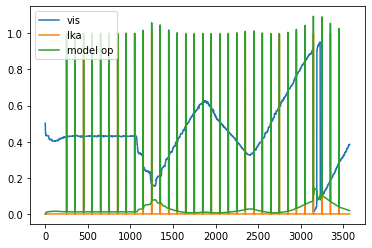

In [166]:
fig,ax = plt.subplots()

#ax.plot(range(len(vis[2352*n:2352*(n+1)])),vis[2352*n:2352*(n+1)],label='RLD')
#ax.plot(range(len(lka[2352*n:2352*(n+1)])),lka[2352*n:2352*(n+1)],label='lka')
ax.plot(vis,label='vis')
ax.plot(lka,label='lka')
ax.plot(a,label='model op')
ax.legend()

In [167]:
l=[]
for i in range(len(a)):
    if a[i] > 0.2:
        l.append(a[i])

In [245]:
m.test = True
m.recon = False
m.max_count =  len(anml_dl)
m.lka = torch.zeros(1).cuda()
m.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
l1 = range(250,3500,100)
l = [[],[400],[250,400,1000,2400],[1000,1500],[1500],[2400],l1]
m.art_lka = l[-1]#range(0,3500,50)
m.b = 0.1
m.c = 0

In [246]:
anml_item.evaluate(model = m , crit = loss)
c = torch.tensor(anml_item.test_loss)#.median() # normal 

  0%|          | 0/1224 [00:00<?, ?it/s]/home/amr/anaconda3/envs/torch/lib/python3.6/site-packages/ipykernel_launcher.py:97: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


testing...


In [247]:
lka = [i[0][0]for i in m.flag_list]
vis = [i[-1]for i in m.flag_list]

In [248]:
len(anml_dl)

1224

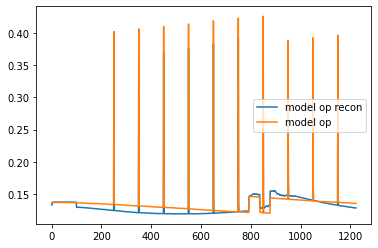

In [253]:
fig,ax = plt.subplots()

#ax.plot(range(len(vis[-3577:])),vis[-3577:],label='RLD')
#ax.plot(range(len(lka[-3577:])),lka[-3577:],label='lka')
ax.plot(a,label='model op recon')
ax.plot(c,label='model op')
ax.legend()

In [131]:
#fig.savefig('Models/publication/recon_hist_vis/bce/15/i.png',dpi=300)

In [132]:
#np.save('Models/publication/recon_hist_vis/bce/15/attack.npy',c)

In [133]:
c[:1000].max()

tensor(0.3875)

In [134]:
#fig.savefig('Documents/case7.png')

In [135]:
c[350]

tensor(0.3875)

In [136]:
b=c

In [137]:
c = 0
l = []
for i in b:
    c+=1
    if  i > 0.28 :
        l.append(i)


In [138]:
len(l)

33

In [139]:
l = l[1::2]

In [142]:
q=np.array(l)[0:5].max()
w=np.array(l)[0:5].min()

In [143]:
(np.array(l) <= q) == (np.array(l) >= w)

array([ True,  True,  True,  True,  True, False,  True, False, False,
       False,  True,  True, False, False, False, False])

In [144]:
c = 0
l = []
for i in b:
    c+=1
    if  i > 0.3 :
        l.append(i)


In [145]:
l = l[1::2]

In [146]:
r=np.array(l)[0:4].max()
t=np.array(l)[0:4].min()

In [147]:
(np.array(l) <= r) == (np.array(l) >= t)

array([ True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False])

In [148]:
#cbs.save_all('Models/publication/enhanced predict lka/temp',learn = learn,model=m ,opt=opt)

In [149]:
loss = mse()

In [43]:
lka_list = []
vis_list = []
op_list = []
for i in range(1,8,1):
    m =  unet_seq(bs,seq_len).cuda()
    cbs.load_all('publication/predict lka with dec vis/mse/',model=m,opt=opt,learn=learn)
    m.test = True
    m.max_count = len(v4_anml_dl)
    m.vis = torch.tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
         0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.]).cuda()
    m.art_lka = l[i-1]
    
    v4_anml_item.evaluate(model = m , crit = loss)
    op_list.append( torch.tensor(v4_anml_item.test_loss))#.median() # Anomaly 
   
    lka_list.append([i[0][0]for i in m.flag_list])
    vis_list.append([i[-1]for i in m.flag_list])
    
    #fig,ax = plt.subplots()
    #ax.plot(range(len(b)),list(b),label='model op')
    

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(vis[-3576:])),vis[-3576:],label='vis')
    #ax.plot(range(len(lka)),lka,label='lka')
    #ax.legend()

    
    #path = f'Models/publication/recon_hist_dec_vis/mse/{i}/'
    #fig.savefig(f'{path}i.png',dpi=300,,bbox_inches = 'tight',pad_inches=0.1)
    #save(path,[b],names=['attack'])

/home/amr/.local/lib/python3.6/site-packages/ipykernel_launcher.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  0%|          | 4/3577 [00:00<01:44, 34.17it/s]

testing...


  0%|          | 3/3577 [00:00<02:08, 27.92it/s]/s]

testing...


 11%|█▏        | 409/3577 [00:05<00:42, 74.02it/s]

...

 94%|█████████▍| 3368/3577 [00:24<00:01, 140.98it/s]

fake


 97%|█████████▋| 3470/3577 [00:24<00:00, 140.63it/s]

fake


100%|█████████▉| 3572/3577 [00:25<00:00, 139.75it/s]

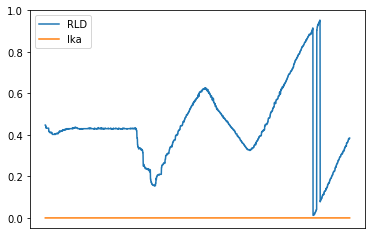

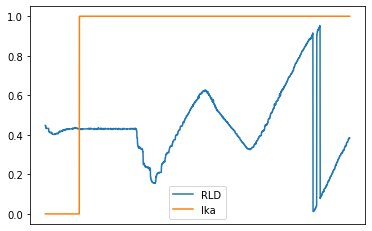

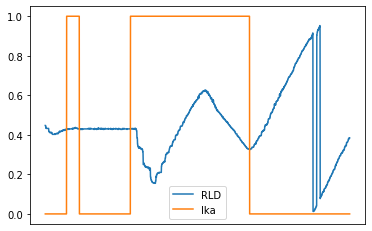

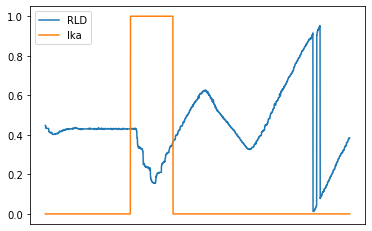

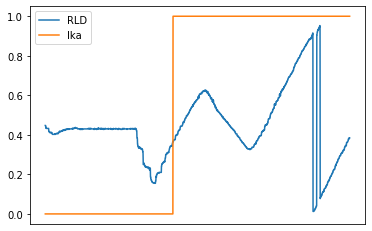

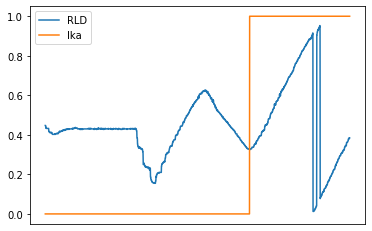

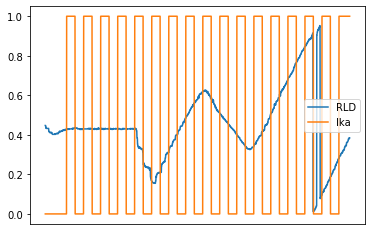

In [45]:
d = 1
#label = ['a','b','c','d','e','f','g','h','i']
for i in range(len(op_list)):
    fig,ax = plt.subplots()
    plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
    
    
    #plt.xlabel(f'({label[i-1]})',fontsize=18)
    #plt.yticks(ticks=[])
    #ax.plot(range(len(op_list[i][1:])),list(op_list[i][1:]),label='model op')
    ax.plot(range(len(vis_list[i][1:])),vis_list[i][1:],label='RLD')
    ax.plot(range(len(lka_list[i])),lka_list[i],label='lka')
    ax.legend()
    path = 'Models/publication/predict lka with dec vis/mse/'
    fig.savefig(f'{i}.png' , format = 'png' , dpi=300,bbox_inches = 'tight',pad_inches=0.1)
    #np.save(f'{path}{d+i}/attack.npy',op_list[i])